## 1. Imports

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import layers, models, regularizers

from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.applications.densenet import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = Path("../data")
IMAGES_DIR = DATA_DIR / "images"
MASKS_DIR = DATA_DIR / "masks"
CSV_PATH = DATA_DIR / "GroundTruth.csv"

SPLIT_RATIO = "80:20"

SPLIT_CONFIGS = {
    "80:20": {"test_size": 0.20, "epochs": 30, "learning_rate": 0.0001, "batch_size": 32},
    "70:30": {"test_size": 0.30, "epochs": 20, "learning_rate": 0.000001, "batch_size": 32},
    "40:60": {"test_size": 0.60, "epochs": 30, "learning_rate": 0.0001, "batch_size": 32},
}

config = SPLIT_CONFIGS[SPLIT_RATIO]

IMG_SIZE = (224, 224)
BATCH_SIZE = config["batch_size"]
EPOCHS = config["epochs"]
LEARNING_RATE = config["learning_rate"]

USE_DULL_RAZOR = True
USE_ENCODER_DECODER_SEGMENTATION = True
TRAIN_SEGMENTER = True

BEST_MODEL_PATH = "best_deepskin_densenet169_undersampling.keras"
FINAL_MODEL_PATH = "deepskin_densenet169_undersampling_final.keras"
SEGMENTER_MODEL_PATH = "encoder_decoder_segmenter.keras"

classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]
class_code = {label: idx for idx, label in enumerate(classes)}
class_name = {idx: label for label, idx in class_code.items()}

print("Configuração:", SPLIT_RATIO)
print("IMG_SIZE:", IMG_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("EPOCHS:", EPOCHS)
print("LEARNING_RATE:", LEARNING_RATE)

Configuração: 80:20
IMG_SIZE: (224, 224)
BATCH_SIZE: 32
EPOCHS: 30
LEARNING_RATE: 0.0001


In [3]:
def find_image_path(image_id, images_dir):
    for ext in [".jpg", ".jpeg", ".png"]:
        path = images_dir / f"{image_id}{ext}"
        if path.exists():
            return str(path)
    return None


def find_mask_path(image_id, masks_dir):
    if not masks_dir.exists():
        return None

    candidates = [
        masks_dir / f"{image_id}.png",
        masks_dir / f"{image_id}.jpg",
        masks_dir / f"{image_id}_segmentation.png",
        masks_dir / f"{image_id}_mask.png",
        masks_dir / f"{image_id}_segmentation.jpg",
        masks_dir / f"{image_id}_mask.jpg",
    ]

    for path in candidates:
        if path.exists():
            return str(path)

    matches = list(masks_dir.glob(f"{image_id}*"))
    if len(matches) > 0:
        return str(matches[0])

    return None


metadata = pd.read_csv(CSV_PATH)

rows = []
for _, row in metadata.iterrows():
    image_id = str(row["image"])
    image_path = find_image_path(image_id, IMAGES_DIR)

    if image_path is None:
        continue

    label_name = row[classes].idxmax()
    label = class_code[label_name]
    mask_path = find_mask_path(image_id, MASKS_DIR)

    rows.append({
        "image": image_id,
        "image_path": image_path,
        "mask_path": mask_path,
        "class_name": label_name,
        "label": label
    })

df = pd.DataFrame(rows)

print("Total de imagens localizadas:", len(df))
display(df.head())
print("\nDistribuição original:")
print(df["class_name"].value_counts().reindex(classes))
print("\nMáscaras encontradas:", df["mask_path"].notna().sum())

Total de imagens localizadas: 10015


,image,image_path,mask_path,class_name,label
0,ISIC_0024306,../data/images/ISIC_0024306.jpg,../data/masks/ISIC_0024306_segmentation.png,NV,1
1,ISIC_0024307,../data/images/ISIC_0024307.jpg,../data/masks/ISIC_0024307_segmentation.png,NV,1
2,ISIC_0024308,../data/images/ISIC_0024308.jpg,../data/masks/ISIC_0024308_segmentation.png,NV,1
3,ISIC_0024309,../data/images/ISIC_0024309.jpg,../data/masks/ISIC_0024309_segmentation.png,NV,1
4,ISIC_0024310,../data/images/ISIC_0024310.jpg,../data/masks/ISIC_0024310_segmentation.png,MEL,0



Distribuição original:
class_name
MEL      1113
NV       6705
BCC       514
AKIEC     327
BKL      1099
DF        115
VASC      142
Name: count, dtype: int64

Máscaras encontradas: 10015


In [4]:
train_df, test_df = train_test_split(
    df,
    test_size=config["test_size"],
    random_state=SEED,
    stratify=df["label"]
)

print("Treino original:", len(train_df))
print("Teste:", len(test_df))

print("\nDistribuição treino antes do undersampling:")
print(train_df["class_name"].value_counts().reindex(classes))

print("\nDistribuição teste final:")
print(test_df["class_name"].value_counts().reindex(classes))

Treino original: 8012
Teste: 2003

Distribuição treino antes do undersampling:
class_name
MEL       890
NV       5364
BCC       411
AKIEC     262
BKL       879
DF         92
VASC      114
Name: count, dtype: int64

Distribuição teste final:
class_name
MEL       223
NV       1341
BCC       103
AKIEC      65
BKL       220
DF         23
VASC       28
Name: count, dtype: int64


In [5]:
def apply_undersampling(dataframe, label_column="label", random_state=SEED):
    counts = dataframe[label_column].value_counts()
    min_count = counts.min()

    balanced_parts = []

    for label_value in sorted(counts.index):
        class_df = dataframe[dataframe[label_column] == label_value]
        sampled_df = class_df.sample(
            n=min_count,
            random_state=random_state,
            replace=False
        )
        balanced_parts.append(sampled_df)

    balanced_df = pd.concat(balanced_parts, axis=0)
    balanced_df = balanced_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    return balanced_df


train_under_df = apply_undersampling(train_df)

print("Treino após undersampling:", len(train_under_df))
print(train_under_df["class_name"].value_counts().reindex(classes))

Treino após undersampling: 644
class_name
MEL      92
NV       92
BCC      92
AKIEC    92
BKL      92
DF       92
VASC     92
Name: count, dtype: int64


In [6]:
VAL_SIZE_FROM_TRAIN = 0.20

train_fit_df, val_df = train_test_split(
    train_under_df,
    test_size=VAL_SIZE_FROM_TRAIN,
    random_state=SEED,
    stratify=train_under_df["label"]
)

print("Treino usado no fit:", len(train_fit_df))
print("Validação:", len(val_df))
print("Teste final:", len(test_df))

print("\nDistribuição treino final:")
print(train_fit_df["class_name"].value_counts().reindex(classes))

print("\nDistribuição validação:")
print(val_df["class_name"].value_counts().reindex(classes))

Treino usado no fit: 515
Validação: 129
Teste final: 2003

Distribuição treino final:
class_name
MEL      74
NV       74
BCC      74
AKIEC    73
BKL      73
DF       74
VASC     73
Name: count, dtype: int64

Distribuição validação:
class_name
MEL      18
NV       18
BCC      18
AKIEC    19
BKL      19
DF       18
VASC     19
Name: count, dtype: int64


### Etapa de Remoção de Pelos (Dull Razor)

In [7]:
def dull_razor_remove_hair(image_rgb, kernel_size=(9, 9), threshold_value=10, inpaint_radius=6):
    image_rgb = image_rgb.astype(np.uint8)
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    blackhat_blur = cv2.GaussianBlur(blackhat, (3, 3), 0)

    _, mask = cv2.threshold(blackhat_blur, threshold_value, 255, cv2.THRESH_BINARY)

    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    clean_bgr = cv2.inpaint(image_bgr, mask, inpaint_radius, cv2.INPAINT_TELEA)
    clean_rgb = cv2.cvtColor(clean_bgr, cv2.COLOR_BGR2RGB)

    return clean_rgb


def read_rgb_image(path):
    if isinstance(path, bytes):
        path = path.decode("utf-8")

    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)

    if image_bgr is None:
        raise ValueError(f"Não foi possível carregar a imagem: {path}")

    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def load_image_with_optional_dull_razor(path):
    image_rgb = read_rgb_image(path)

    if USE_DULL_RAZOR:
        image_rgb = dull_razor_remove_hair(image_rgb)

    image_rgb = cv2.resize(image_rgb, IMG_SIZE)

    return image_rgb.astype("float32")

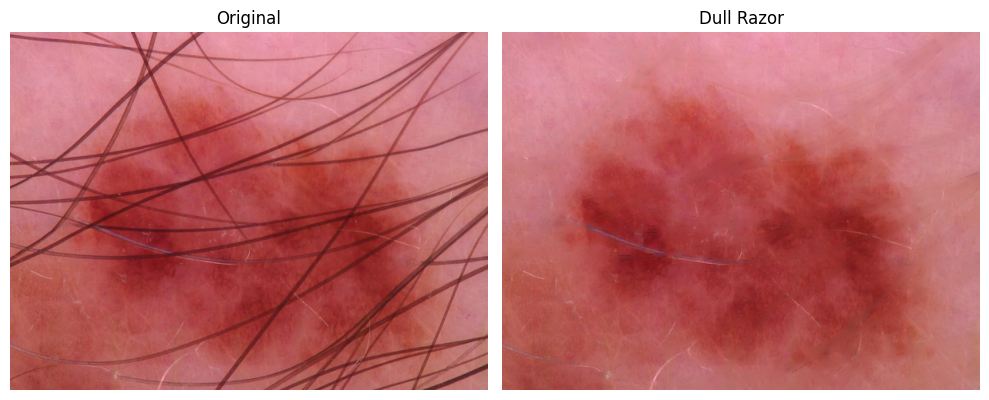

In [8]:
sample_row = train_fit_df.sample(1, random_state=SEED).iloc[0]
sample_original = read_rgb_image(sample_row["image_path"])
sample_clean = dull_razor_remove_hair(sample_original)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_clean)
plt.title("Dull Razor")
plt.axis("off")

plt.tight_layout()
plt.savefig("exemplo_dull_razor.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
print("USE_DULL_RAZOR:", USE_DULL_RAZOR)
print("USE_ENCODER_DECODER_SEGMENTATION:", USE_ENCODER_DECODER_SEGMENTATION)
print("TRAIN_SEGMENTER:", TRAIN_SEGMENTER)

USE_DULL_RAZOR: True
USE_ENCODER_DECODER_SEGMENTATION: True
TRAIN_SEGMENTER: True


In [25]:
USE_DULL_RAZOR = True
USE_ENCODER_DECODER_SEGMENTATION = False
TRAIN_SEGMENTER = False

print("USE_DULL_RAZOR:", USE_DULL_RAZOR)
print("USE_ENCODER_DECODER_SEGMENTATION:", USE_ENCODER_DECODER_SEGMENTATION)
print("TRAIN_SEGMENTER:", TRAIN_SEGMENTER)

USE_DULL_RAZOR: True
USE_ENCODER_DECODER_SEGMENTATION: False
TRAIN_SEGMENTER: False


In [27]:
def load_mask_array(mask_path):
    if isinstance(mask_path, bytes):
        mask_path = mask_path.decode("utf-8")

    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if mask is None:
        raise ValueError(f"Não foi possível carregar a máscara: {mask_path}")

    mask = cv2.resize(mask, IMG_SIZE)
    mask = (mask > 127).astype("float32")
    mask = np.expand_dims(mask, axis=-1)

    return mask


def load_image_and_mask_py(image_path, mask_path):
    image = load_image_with_optional_dull_razor(image_path)
    image = image / 255.0
    mask = load_mask_array(mask_path)
    return image.astype("float32"), mask.astype("float32")


def tf_load_image_and_mask(image_path, mask_path):
    image, mask = tf.numpy_function(
        load_image_and_mask_py,
        [image_path, mask_path],
        [tf.float32, tf.float32]
    )

    image.set_shape((IMG_SIZE[0], IMG_SIZE[1], 3))
    mask.set_shape((IMG_SIZE[0], IMG_SIZE[1], 1))
    return image, mask


def build_segmentation_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=True):
    valid_df = dataframe.dropna(subset=["mask_path"]).copy()

    ds = tf.data.Dataset.from_tensor_slices((
        valid_df["image_path"].values,
        valid_df["mask_path"].values
    ))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(valid_df), seed=SEED)

    ds = ds.map(tf_load_image_and_mask, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


def build_encoder_decoder_segmenter(input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)

    outputs = layers.Conv2D(1, 1, activation="sigmoid", padding="same")(x)

    return models.Model(inputs, outputs, name="encoder_decoder_segmenter")

In [28]:
if USE_ENCODER_DECODER_SEGMENTATION and TRAIN_SEGMENTER:
    seg_train_ds = build_segmentation_dataset(train_fit_df, shuffle=True)
    seg_val_ds = build_segmentation_dataset(val_df, shuffle=False)

    segmenter = build_encoder_decoder_segmenter(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    segmenter.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    seg_callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
        keras.callbacks.ModelCheckpoint(SEGMENTER_MODEL_PATH, monitor="val_loss", save_best_only=True, verbose=1)
    ]

    seg_history = segmenter.fit(
        seg_train_ds,
        validation_data=seg_val_ds,
        epochs=20,
        callbacks=seg_callbacks
    )
else:
    segmenter = None
    print("Segmentador não treinado.")

Segmentador não treinado.


In [29]:
def apply_segmentation_threshold(image_rgb):
    if segmenter is None:
        return image_rgb

    image_resized = cv2.resize(image_rgb.astype("uint8"), IMG_SIZE)
    image_input = image_resized.astype("float32") / 255.0

    pred_mask = segmenter.predict(np.expand_dims(image_input, axis=0), verbose=0)[0]
    binary_mask = (pred_mask > 0.5).astype("uint8")

    segmented = image_resized * binary_mask
    return segmented.astype("float32")


def full_preprocess_for_classifier(path):
    image_rgb = load_image_with_optional_dull_razor(path)

    if USE_ENCODER_DECODER_SEGMENTATION and segmenter is not None:
        image_rgb = apply_segmentation_threshold(image_rgb)

    return image_rgb.astype("float32")


def load_image_for_classification_py(path, label):
    image = full_preprocess_for_classifier(path)
    return image.astype("float32"), np.int32(label)


def tf_load_image_for_classification(path, label):
    image, label = tf.numpy_function(
        load_image_for_classification_py,
        [path, label],
        [tf.float32, tf.int32]
    )

    image.set_shape((IMG_SIZE[0], IMG_SIZE[1], 3))
    label.set_shape(())
    return image, label


def build_classification_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe["image_path"].values,
        dataframe["label"].values.astype("int32")
    ))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)

    ds = ds.map(tf_load_image_for_classification, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

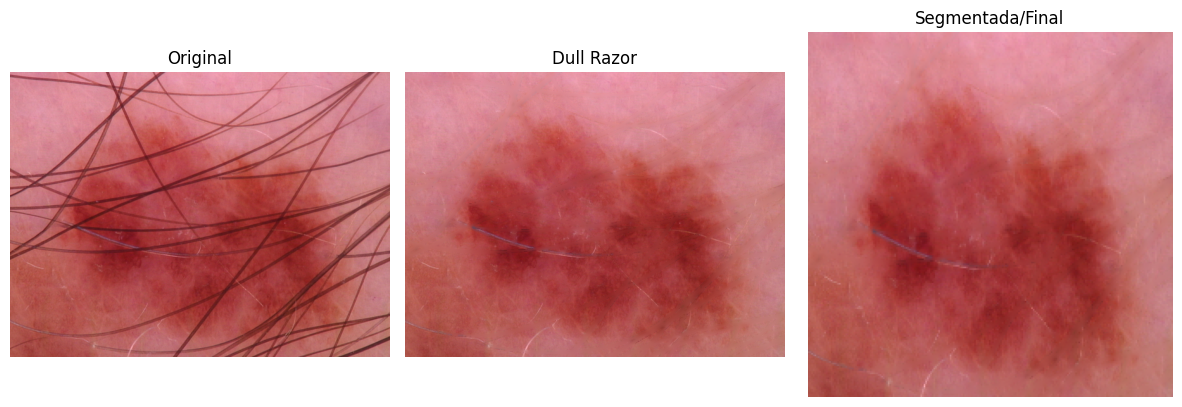

In [30]:
sample_row = train_fit_df.sample(1, random_state=SEED).iloc[0]

original = read_rgb_image(sample_row["image_path"])
dull = dull_razor_remove_hair(original) if USE_DULL_RAZOR else original
processed = full_preprocess_for_classifier(sample_row["image_path"])
processed = np.clip(processed, 0, 255).astype("uint8")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(dull)
plt.title("Dull Razor")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(processed)
plt.title("Segmentada/Final")
plt.axis("off")

plt.tight_layout()
plt.savefig("pipeline_preprocessamento_deepskin.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
train_ds = build_classification_dataset(train_fit_df, shuffle=True)
val_ds = build_classification_dataset(val_df, shuffle=False)
test_ds = build_classification_dataset(test_df, shuffle=False)

print(train_ds)
print(val_ds)
print(test_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [32]:
def build_densenet169_classifier(num_classes=len(classes), input_shape=(224, 224, 3)):
    base_model = DenseNet169(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)

    x = preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="deepskin_densenet169_undersampling")

    return model, base_model


model, base_model = build_densenet169_classifier(
    num_classes=len(classes),
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "deepskin_densenet169_undersampling"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_1 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_3 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet169 (Functional)        │ (None, 7, 7, 1664)     │    12,642,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1664)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       426,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,070,919 (49.86 MB)

 Trainable params: 428,039 (1.63 MB)

 Non-trainable params: 12,642,880 (48.23 MB)

In [33]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=4, min_lr=1e-7, verbose=1),
    keras.callbacks.ModelCheckpoint(BEST_MODEL_PATH, monitor="val_loss", save_best_only=True, verbose=1)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.1171 - loss: 2.8758
Epoch 1: val_loss improved from None to 2.32783, saving model to best_deepskin_densenet169_undersampling.keras

Epoch 1: finished saving model to best_deepskin_densenet169_undersampling.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.1301 - loss: 2.7847 - val_accuracy: 0.1938 - val_loss: 2.3278 - learning_rate: 1.0000e-04
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 734ms/step - accuracy: 0.1632 - loss: 2.5099
Epoch 2: val_loss improved from 2.32783 to 2.19115, saving model to best_deepskin_densenet169_undersampling.keras

Epoch 2: finished saving model to best_deepskin_densenet169_undersampling.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 965ms/step - accuracy: 0.1767 - loss: 2.4969 - val_accuracy: 0.3101 - val_loss: 2.1911 - learning_rate: 1.0000e-04
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - accuracy: 0.2176 - loss: 2.3699
Epoch 3: val_loss improved from 2.19115 to 2.09103, saving model t

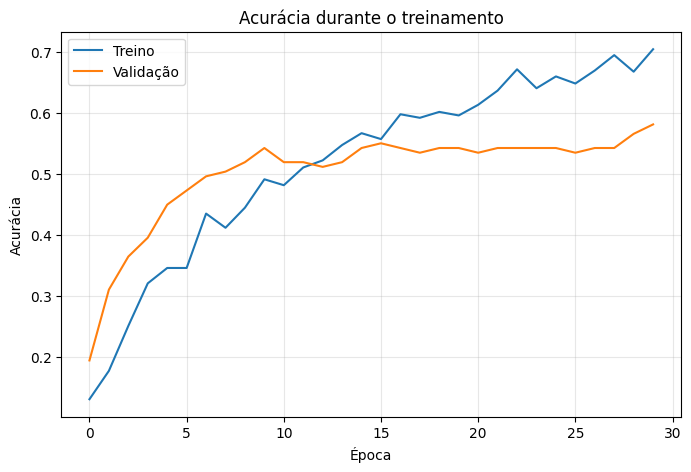

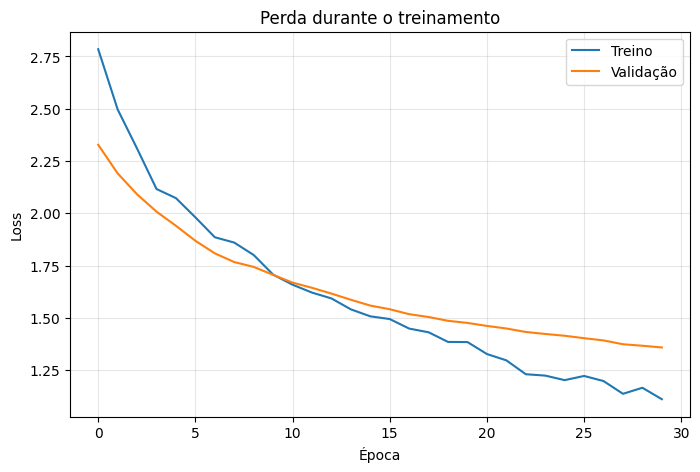

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validação")
plt.title("Acurácia durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("acuracia_densenet169_undersampling.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.title("Perda durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("loss_densenet169_undersampling.png", dpi=300, bbox_inches="tight")
plt.show()

In [36]:
best_model = keras.models.load_model(BEST_MODEL_PATH)

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Relatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

acc = accuracy_score(y_true, y_pred)

macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

weighted_precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
weighted_recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("\nMÉTRICAS GERAIS DO MODELO")
print(f"Accuracy: {acc:.4f}")

print("\nMacro Average:")
print(f"  Precision: {macro_precision:.4f}")
print(f"  Recall: {macro_recall:.4f}")
print(f"  F1-Score: {macro_f1:.4f}")

print("\nWeighted Average:")
print(f"  Precision: {weighted_precision:.4f}")
print(f"  Recall: {weighted_recall:.4f}")
print(f"  F1-Score: {weighted_f1:.4f}")

Relatório de Classificação:
              precision    recall  f1-score   support

         MEL     0.2812    0.4036    0.3315       223
          NV     0.9284    0.5996    0.7286      1341
         BCC     0.3661    0.3981    0.3814       103
       AKIEC     0.2338    0.5538    0.3288        65
         BKL     0.3517    0.3773    0.3640       220
          DF     0.0941    0.6957    0.1658        23
        VASC     0.1862    0.9643    0.3121        28

    accuracy                         0.5477      2003
   macro avg     0.3488    0.5703    0.3732      2003
weighted avg     0.7216    0.5477    0.6012      2003


MÉTRICAS GERAIS DO MODELO
Accuracy: 0.5477

Macro Average:
  Precision: 0.3488
  Recall: 0.5703
  F1-Score: 0.3732

Weighted Average:
  Precision: 0.7216
  Recall: 0.5477
  F1-Score: 0.6012


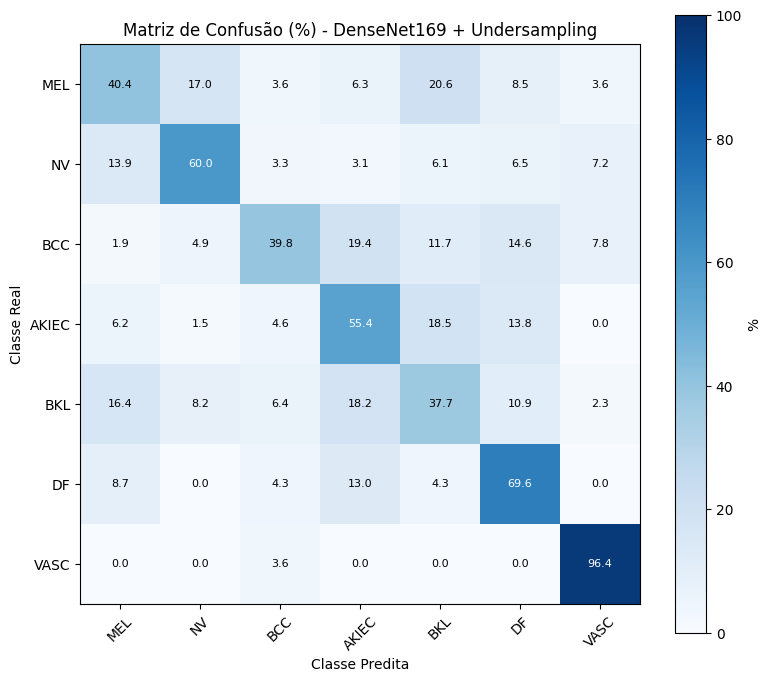

In [37]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
cm_percent = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100
cm_percent = np.nan_to_num(cm_percent)

plt.figure(figsize=(8, 7))
im = plt.imshow(cm_percent, interpolation="nearest", cmap="Blues", vmin=0, vmax=100)
plt.title("Matriz de Confusão (%) - DenseNet169 + Undersampling")
plt.colorbar(im, label="%")

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        color = "white" if cm_percent[i, j] > 50 else "black"
        plt.text(j, i, f"{cm_percent[i, j]:.1f}", ha="center", va="center", color=color, fontsize=8)

plt.ylabel("Classe Real")
plt.xlabel("Classe Predita")
plt.tight_layout()
plt.savefig("matriz_confusao_percent_densenet169_undersampling.png", dpi=300, bbox_inches="tight")
plt.show()

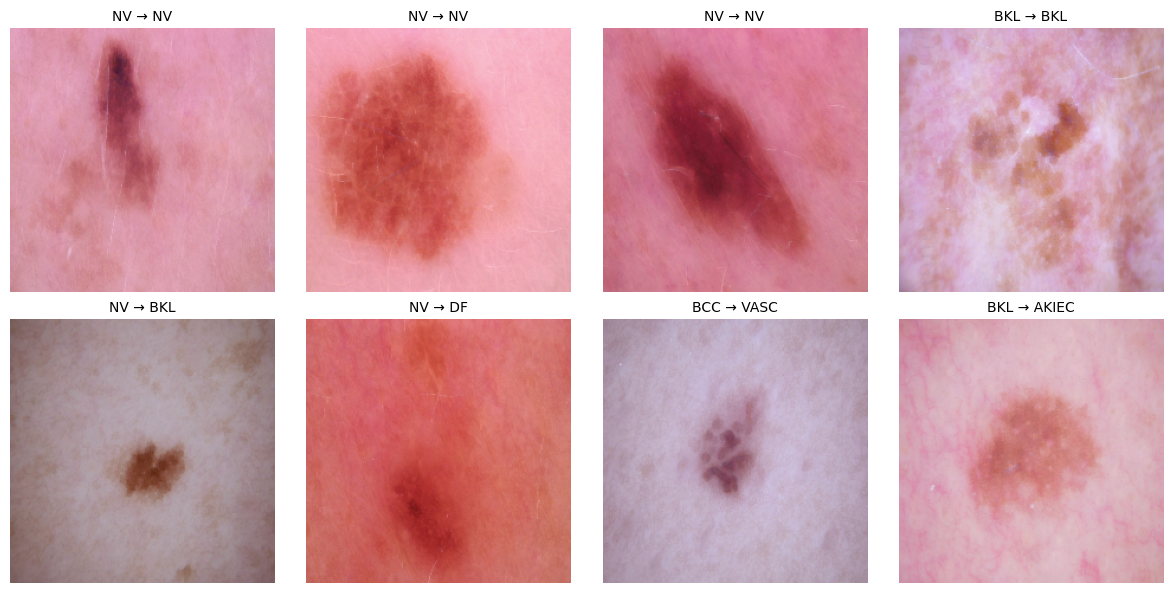

In [38]:
test_eval_df = test_df.copy().reset_index(drop=True)
test_eval_df["y_true"] = y_true
test_eval_df["y_pred"] = y_pred
test_eval_df["correct"] = test_eval_df["y_true"] == test_eval_df["y_pred"]

correct_samples = test_eval_df[test_eval_df["correct"]].head(4)
incorrect_samples = test_eval_df[~test_eval_df["correct"]].head(4)

samples_to_plot = pd.concat([correct_samples, incorrect_samples], axis=0).reset_index(drop=True)

plt.figure(figsize=(12, 6))

for i, row in samples_to_plot.iterrows():
    image = full_preprocess_for_classifier(row["image_path"])
    image = np.clip(image, 0, 255).astype("uint8")

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)

    true_label = class_name[int(row["y_true"])]
    pred_label = class_name[int(row["y_pred"])]

    plt.title(f"{true_label} → {pred_label}", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.savefig("exemplos_classificacao_densenet169.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
best_model.save(FINAL_MODEL_PATH)

print("Modelo final salvo em:", FINAL_MODEL_PATH)
print("Melhor checkpoint salvo em:", BEST_MODEL_PATH)

Modelo final salvo em: deepskin_densenet169_undersampling_final.keras
Melhor checkpoint salvo em: best_deepskin_densenet169_undersampling.keras


## 18. Observações finais

Se os resultados ficarem abaixo dos reportados no artigo, verifique:

1. se existem máscaras suficientes para treinar o encoder-decoder;
2. se o Dull Razor está removendo apenas pelos ou alterando a lesão;
3. se o teste está preservado sem balanceamento;
4. se o artigo aplicou sampling antes ou depois do split;
5. se os resultados reportados foram obtidos em conjunto de teste balanceado.